# EDA

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from pathlib import Path
from collections import Counter
import seaborn as sns
import re

# ------------------------
# 1. Cargar JSONL en DataFrame
# ------------------------
path = Path("../data/interim/debates.jsonl")
df = pd.read_json(path, lines=True)

# Limpieza básica
df["intervencion"] = df["intervencion"].fillna("").astype(str)
df["locutor"] = df["locutor"].fillna("DESCONOCIDO").astype(str)
df["cuerpo"] = df["cuerpo"].fillna("desconocido").astype(str)

# ------------------------
# 2. Agregar métricas
# ------------------------
df["n_palabras"] = df["intervencion"].apply(lambda s: len(s.split()))
df["n_caracteres"] = df["intervencion"].str.len()

# ------------------------
# 3. Contar intervenciones
# ------------------------
total_intervenciones = len(df)
print(f"Total de intervenciones: {total_intervenciones:,}")

# ------------------------
# 4. Contar palabras totales
# ------------------------
total_palabras = df["n_palabras"].sum()
print(f"Total de palabras: {total_palabras:,}")

# ------------------------
# 5. Promedio de intervenciones por documento
# ------------------------
interv_x_doc = df.groupby("file_name").size()
print(f"Promedio de intervenciones por documento: {interv_x_doc.mean():.2f}")

# ------------------------
# 6. Promedio de extensión (boxplot)
# ------------------------
plt.figure(figsize=(8,5))
sns.boxplot(x="cuerpo", y="n_palabras", data=df)
plt.title("Distribución de longitud de intervenciones por cámara")
plt.xlabel("Cámara")
plt.ylabel("Cantidad de palabras")
plt.tight_layout()
plt.show()

# ------------------------
# 7. Personas con más intervenciones (sin Presidente)
# ------------------------
top_locutores = (
    df[~df["locutor"].str.contains("PRESIDENTE", case=False)]
    .groupby("locutor")
    .size()
    .sort_values(ascending=False)
    .head(15)
)
plt.figure(figsize=(8,6))
top_locutores.plot(kind="barh", color="steelblue")
plt.gca().invert_yaxis()
plt.title("Top 15 locutores con más intervenciones (sin Presidente)")
plt.xlabel("Cantidad de intervenciones")
plt.tight_layout()
plt.show()

# ------------------------
# 8. Nube de palabras (quitando artículos, preps, etc.)
# ------------------------
stopwords = set([
    "de","la","que","el","en","y","a","los","del","se","las","por","un",
    "con","no","una","su","para","es","al","lo","como","más","pero","sus",
    "le","ya","o","fue","ha","si","sin","sobre","este","también","me","hasta",
    "hay","donde","han","ser","uno","entre","cuando","muy","años","desde",
    "porque","qué","solo","nos","durante","todo","esta","todos","sí","pues",
    "ni","misma","ese","otra","tanto","otros","ese","esa","ese","esas","estos",
])

texto = " ".join(df["intervencion"].tolist())
texto = re.sub(r"[^a-zA-ZáéíóúÁÉÍÓÚñÑ ]", " ", texto)
texto = " ".join([t.lower() for t in texto.split() if t.lower() not in stopwords])

wc = WordCloud(width=900, height=500, background_color="white", collocations=False).generate(texto)
plt.figure(figsize=(12,6))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("Nube de palabras de intervenciones")
plt.show()

# ------------------------
# 9. Composición por cámara (% de palabras)
# ------------------------
palabras_por_cuerpo = df.groupby("cuerpo")["n_palabras"].sum()
palabras_por_cuerpo_pct = (palabras_por_cuerpo / palabras_por_cuerpo.sum()) * 100
print("\nPorcentaje de palabras por cámara:")
print(palabras_por_cuerpo_pct.round(2))

plt.figure(figsize=(6,6))
palabras_por_cuerpo_pct.plot(kind="pie", autopct="%.1f%%", startangle=90)
plt.title("Composición por cámara (palabras)")
plt.ylabel("")
plt.show()

# ------------------------
# 10. Bonus: evolución temporal
# ------------------------
df["fecha"] = pd.to_datetime(df["fecha"], errors="coerce")
df["año"] = df["fecha"].dt.year
evol = df.groupby("año")["n_palabras"].sum().dropna()

plt.figure(figsize=(8,5))
evol.plot(marker="o")
plt.title("Evolución del total de palabras por año")
plt.xlabel("Año")
plt.ylabel("Palabras totales")
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()


C:\Users\flala\AppData\Local\Temp\ipykernel_3536\5844124.py:13: FutureWarning: Passing literal json to 'read_json' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  df = pd.read_json(path, lines=True)


ValueError: Expected object or value

In [2]:
#Importación de librerías 

import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from pathlib import Path
from collections import Counter
import seaborn as sns
import re

In [3]:
# ------------------------
# 1. Cargar JSONL en DataFrame
# ------------------------
path = Path("../data/interim/debates.jsonl")
df = pd.read_json(path, lines=True)

C:\Users\flala\AppData\Local\Temp\ipykernel_3536\3819440878.py:5: FutureWarning: Passing literal json to 'read_json' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  df = pd.read_json(path, lines=True)


ValueError: Expected object or value

In [2]:
from pathlib import Path
import json
import pandas as pd

path = Path("../data/interim/debates.jsonl")  # o el path donde lo subiste
good, bad = [], []

with open(path, "r", encoding="utf-8") as f:
    for i, line in enumerate(f, 1):
        s = line.strip()
        if not s:
            continue
        try:
            obj = json.loads(s)
            good.append(obj)
        except Exception as e:
            bad.append((i, str(e), s[:200]))

print(f"✅ {len(good)} líneas válidas | ❌ {len(bad)} líneas con error")
if bad:
    for i, e, s in bad[:5]:
        print(f"Línea {i}: {e}\n{s}\n")

clean_path = path.with_name("debates_clean.jsonl")
with open(clean_path, "w", encoding="utf-8") as out:
    for obj in good:
        json.dump(obj, out, ensure_ascii=False)
        out.write("\n")

df = pd.read_json(clean_path, lines=True)
print("DataFrame:", df.shape)
print(df.columns)


✅ 139493 líneas válidas | ❌ 0 líneas con error
DataFrame: (139493, 7)
Index(['file_name', 'n_legislatura', 'cuerpo', 'fecha', 'locutor',
       'encabezado', 'intervencion'],
      dtype='object')


In [3]:
# Normalizo locutor
loc = df["locutor"].fillna("").astype(str).str.strip()

# 1) Vacíos
mask_empty = loc.eq("")

# 2) ¿Empieza con Señor/Señora? (con y sin tilde)
#    Acepta: "Señor", "Señora", "Senor", "Senora"
#    y luego cualquiera de: espacio, punto, dos puntos, guion
pat = r"^(señor(?:a)?|senor(?:a)?)(?:\s|\.|:|-)\b"
mask_se_sra = loc.str.match(pat, case=False, na=False)

# 3) Todo lo que sea vacío o NO matchee el patrón
mask_bad = mask_empty | (~mask_se_sra)

# Tabla de observaciones "problemáticas"
cols_ver = ["file_name", "fecha", "cuerpo", "locutor", "encabezado", "intervencion"]
df_bad = df.loc[mask_bad, cols_ver].copy()

print(f"Total filas: {len(df):,}")
print(f"Vacías: {mask_empty.sum():,}")
print(f"No 'Señor/Señora': {(~mask_se_sra).sum():,}")
print(f"Union (vacías o no 'Señor/Señora'): {mask_bad.sum():,}")

# Muestra de las primeras 30
display(df_bad.head(30))

# (Opcional) Top prefijos raros para inspección
prefijos = loc[mask_bad].str.split().str[0].str[:20]
print("\nTop prefijos/primeras palabras entre 'raros':")
print(prefijos.value_counts().head(25))

Total filas: 139,493
Vacías: 0
No 'Señor/Señora': 379
Union (vacías o no 'Señor/Señora'): 379


,file_name,fecha,cuerpo,locutor,encabezado,intervencion
62,48_2017-12-15_a.g..txt,2017-12-15,a.g.,DESCONOCIDO,1) TEXTO DE LA CITACIÓN 2) ASISTENCIA VIRGINIA...,2) Asistencia....................................
181,48_2019-03-01_a.g..txt,2019-03-01,a.g.,DESCONOCIDO,1) TEXTO DE LA CITACIÓN 2) ASISTENCIA VIRGINIA...,2) Asistencia....................................
221,48_2019-07-03_a.g..txt,2019-07-03,a.g.,DESCONOCIDO,1) TEXTO DE LA CITACIÓN 2) ASISTENCIA VIRGINIA...,2) Asistencia....................................
249,48_2019-09-15_a.g..txt,2019-09-15,a.g.,DESCONOCIDO,1) TEXTO DE LA CITACIÓN 2) ASISTENCIA VIRGINIA...,2) Asistencia....................................
260,49_2020-05-05_a.g..txt,2020-05-05,a.g.,DESCONOCIDO,1) TEXTO DE LA CITACIÓN 2) ASISTENCIA FERNANDO...,2) Asistencia....................................
261,49_2020-05-13_a.g..txt,2020-05-13,a.g.,DESCONOCIDO,ORDEN DEL DÍA,2) Asistencia....................................
272,49_2020-10-21_a.g..txt,2020-10-21,a.g.,DESCONOCIDO,ORDEN DEL DÍA,2) Asistencia....................................
273,49_2020-12-15_a.g..txt,2020-12-15,a.g.,DESCONOCIDO,1) TEXTO DE LA CITACIÓN 2) ASISTENCIA FERNANDO...,2) Asistencia....................................
287,49_2021-03-01_a.g..txt,2021-03-01,a.g.,DESCONOCIDO,1) TEXTO DE LA CITACIÓN 2) ASISTENCIA FERNANDO...,2) Asistencia....................................
330,49_2021-11-16_a.g..txt,2021-11-16,a.g.,DESCONOCIDO,1) TEXTO DE LA CITACIÓN 2) ASISTENCIA FERNANDO...,2) Asistencia....................................



Top prefijos/primeras palabras entre 'raros':
locutor
DESCONOCIDO    378
SEÑORA           1
Name: count, dtype: int64


In [7]:
df.head()

,file_name,n_legislatura,cuerpo,fecha,locutor,encabezado,intervencion
0,47_2012-05-16_crr.txt,47,crr,2012-05-16,SEÑOR PRESIDENTE (Bianchi),ORDEN DEL DÍA,En el palco de la izquierda se encuentra el Co...
1,47_2012-05-16_crr.txt,47,crr,2012-05-16,SEÑOR BEROIS,ORDEN DEL DÍA,Señor Presidente: agradezco al Partido Naciona...
2,47_2012-05-16_crr.txt,47,crr,2012-05-16,SEÑOR PRESIDENTE (Orrico),ORDEN DEL DÍA,Tiene la palabra el señor Diputado Radío.
3,47_2012-05-16_crr.txt,47,crr,2012-05-16,SEÑOR RADÍO,ORDEN DEL DÍA,Señor Presidente: es para mí un honor particip...
4,47_2012-05-16_crr.txt,47,crr,2012-05-16,SEÑOR PRESIDENTE (Orrico),ORDEN DEL DÍA,Tiene la palabra el señor Diputado Arocena.\nE...


In [4]:
# Limpieza básica
df["intervencion"] = df["intervencion"].fillna("").astype(str)
df["locutor"] = df["locutor"].fillna("DESCONOCIDO").astype(str)
df["cuerpo"] = df["cuerpo"].fillna("desconocido").astype(str)

In [5]:
# ------------------------
# 2. Agregar métricas
# ------------------------
df["n_palabras"] = df["intervencion"].apply(lambda s: len(s.split()))
df["n_caracteres"] = df["intervencion"].str.len()

In [6]:
df

,file_name,n_legislatura,cuerpo,fecha,locutor,encabezado,intervencion,n_palabras,n_caracteres
0,48_2017-08-01_a.g..txt,48,a.g.,2017-08-01,SEÑOR SECRETARIO,ORDEN DEL DÍA,"«El Poder Ejecutivo remite mensaje, en cumplim...",69,410
1,48_2017-08-01_a.g..txt,48,a.g.,2017-08-01,SEÑOR SECRETARIO,ORDEN DEL DÍA,A la sesión extraordinaria del 17 de mayo falt...,299,1814
2,48_2017-08-01_a.g..txt,48,a.g.,2017-08-01,SEÑORA PAYSSÉ,CONSEJO DIRECTIVO DE LA INSTITUCIÓN NACIONAL D...,Pido la palabra para una cuestión de orden.,8,43
3,48_2017-08-01_a.g..txt,48,a.g.,2017-08-01,SEÑOR PRESIDENTE,CONSEJO DIRECTIVO DE LA INSTITUCIÓN NACIONAL D...,Tiene la palabra la señora le gisladora.,7,40
4,48_2017-08-01_a.g..txt,48,a.g.,2017-08-01,SEÑOR PRESIDENTE,CONSEJO DIRECTIVO DE LA INSTITUCIÓN NACIONAL D...,Se va a votar..\n–85 en 88. Afirmativa.\nLa As...,572,3420
...,...,...,...,...,...,...,...,...,...
139488,50_2025-10-27_css.txt,50,css,2025-10-27,SEÑORA PRESIDENTA,10) LUIS ALBERTO HEBER. SUBSIDIO,De conformidad con lo que establece el numeral...,58,322
139489,50_2025-10-27_css.txt,50,css,2025-10-27,SEÑORA PRESIDENTA,11) SUSPENSIÓN DE LAS SESIONES ORDINARIAS,Léase una moción llegada a la mesa..\nSEÑOR SE...,41,245
139490,50_2025-10-27_css.txt,50,css,2025-10-27,SEÑORA PRESIDENTA,11) SUSPENSIÓN DE LAS SESIONES ORDINARIAS,Se va a votar..\n–29 en 29. Afirmativa. UNANIM...,14,81
139491,50_2025-10-27_css.txt,50,css,2025-10-27,SEÑORA PRESIDENTA,12) SOLICITUDES DE LICENCIA E,Se va a votar si se concede la licencia solici...,13,74


In [7]:
# ------------------------
# 3. Contar intervenciones
# ------------------------
total_intervenciones = len(df)
print(f"Total de intervenciones: {total_intervenciones:,}")


Total de intervenciones: 139,493


In [8]:
#Total de intervenciones sin contar presidente

# Normalizar columna locutor por si tiene NaN
df['locutor'] = df['locutor'].fillna('').str.strip()

# Definir qué se considera “presidente” (masc. y fem.)
mask_presidente = df['locutor'].str.contains(r'president[ea]', case=False, regex=True)

# Contar
n_pres = mask_presidente.sum()
n_no_pres = (~mask_presidente).sum()
total = len(df)

print(f"Total intervenciones: {total:,}")
print(f"De presidentes: {n_pres:,}  ({n_pres/total:.1%})")
print(f"No presidentes: {n_no_pres:,}  ({n_no_pres/total:.1%})")


Total intervenciones: 139,493
De presidentes: 73,804  (52.9%)
No presidentes: 65,689  (47.1%)


In [9]:

# Limpieza mínima
df["locutor"] = df["locutor"].fillna("").astype(str)
df["cuerpo"] = df["cuerpo"].fillna("DESCONOCIDO")

# Clasificamos intervenciones según si son de Presidencia o no
df["es_presidencia"] = df["locutor"].str.contains(r'\bPRESIDENT(A|E)\b', case=False, regex=True)

# Contamos por cámara y condición
tabla_presidencia = (
    df.groupby(["cuerpo", "es_presidencia"])
      .size()
      .reset_index(name="intervenciones")
)

# Etiquetas legibles
tabla_presidencia["tipo"] = tabla_presidencia["es_presidencia"].map({True: "Presidencia", False: "No Presidencia"})

# Totales por cámara
tabla_presidencia["total_cuerpo"] = tabla_presidencia.groupby("cuerpo")["intervenciones"].transform("sum")
tabla_presidencia["porcentaje"] = 100 * tabla_presidencia["intervenciones"] / tabla_presidencia["total_cuerpo"]

# Ordenar columnas
tabla_presidencia = tabla_presidencia[["cuerpo", "tipo", "intervenciones", "total_cuerpo", "porcentaje"]]

from IPython.display import display
display(
    tabla_presidencia.style.format({
        "intervenciones": "{:,.0f}",
        "total_cuerpo": "{:,.0f}",
        "porcentaje": "{:.2f}%"
    })
)


/var/folders/rt/c3kdzpyd2fdflbk7kfmpz4sh0000gn/T/ipykernel_95170/3336286.py:6: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df["es_presidencia"] = df["locutor"].str.contains(r'\bPRESIDENT(A|E)\b', case=False, regex=True)


,cuerpo,tipo,intervenciones,total_cuerpo,porcentaje
0,a.g.,No Presidencia,"1,034","1,717",60.22%
1,a.g.,Presidencia,683,"1,717",39.78%
2,c.p.,No Presidencia,"2,763","5,349",51.65%
3,c.p.,Presidencia,"2,586","5,349",48.35%
4,crr,No Presidencia,"12,979","32,876",39.48%
5,crr,Presidencia,"19,897","32,876",60.52%
6,css,No Presidencia,"48,915","99,551",49.14%
7,css,Presidencia,"50,636","99,551",50.86%


In [10]:
# ------------------------
# 4. Contar palabras totales
# ------------------------
total_palabras = df["n_palabras"].sum()
print(f"Total de palabras: {total_palabras:,}")

Total de palabras: 30,180,634


In [11]:
# ------------------------
# 5. Promedio de intervenciones por documento
# ------------------------
interv_x_doc = df.groupby("file_name").size()
print(f"Promedio de intervenciones por documento: {interv_x_doc.mean():.2f}")


Promedio de intervenciones por documento: 69.75


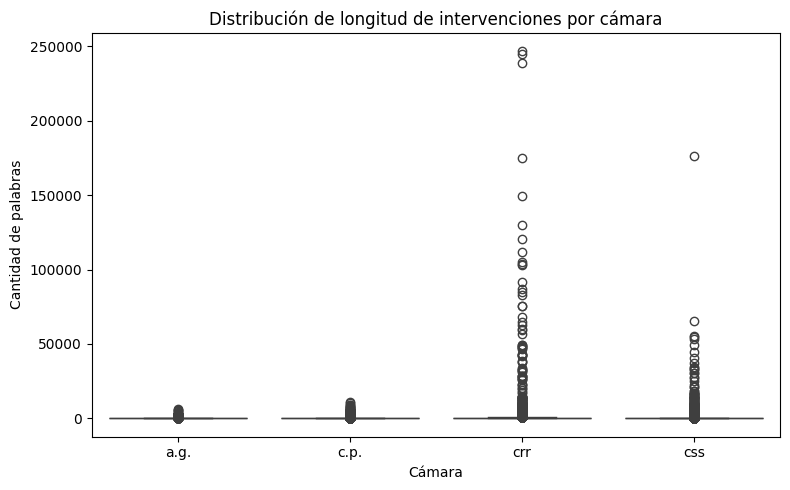

In [12]:
# ------------------------
# 6. Promedio de extensión (boxplot)
# ------------------------
plt.figure(figsize=(8,5))
sns.boxplot(x="cuerpo", y="n_palabras", data=df)
plt.title("Distribución de longitud de intervenciones por cámara")
plt.xlabel("Cámara")
plt.ylabel("Cantidad de palabras")
plt.tight_layout()
plt.show()

In [ ]:
df

,file_name,n_legislatura,cuerpo,fecha,locutor,encabezado,intervencion,n_palabras,n_caracteres
0,47_2012-05-16_crr.txt,47,crr,2012-05-16,SEÑOR PRESIDENTE (Bianchi),ORDEN DEL DÍA,En el palco de la izquierda se encuentra el Co...,48,336
1,47_2012-05-16_crr.txt,47,crr,2012-05-16,SEÑOR BEROIS,ORDEN DEL DÍA,Señor Presidente: agradezco al Partido Naciona...,1036,6439
2,47_2012-05-16_crr.txt,47,crr,2012-05-16,SEÑOR PRESIDENTE (Orrico),ORDEN DEL DÍA,Tiene la palabra el señor Diputado Radío.,7,41
3,47_2012-05-16_crr.txt,47,crr,2012-05-16,SEÑOR RADÍO,ORDEN DEL DÍA,Señor Presidente: es para mí un honor particip...,857,5352
4,47_2012-05-16_crr.txt,47,crr,2012-05-16,SEÑOR PRESIDENTE (Orrico),ORDEN DEL DÍA,Tiene la palabra el señor Diputado Arocena.\nE...,606,3812
...,...,...,...,...,...,...,...,...,...
78646,50_2025-09-10_css.txt,50,css,2025-09-10,SEÑOR PRESIDENTE (Sebastián Sabini),DESIGNACIÓN COMO EMBAJADOR,Tiene la palabra el señor senador.,6,34
78647,50_2025-09-10_css.txt,50,css,2025-09-10,SEÑOR OJEDA,DESIGNACIÓN COMO EMBAJADOR,Señor presidente: simplemente quiero expresar ...,138,820
78648,50_2025-09-10_css.txt,50,css,2025-09-10,SEÑOR CAGGIANI,DESIGNACIÓN COMO EMBAJADOR,Pido la palabra para fundar el voto.,7,36
78649,50_2025-09-10_css.txt,50,css,2025-09-10,SEÑOR PRESIDENTE (Sebastián Sabini),DESIGNACIÓN COMO EMBAJADOR,Tiene la palabra el señor senador.,6,34


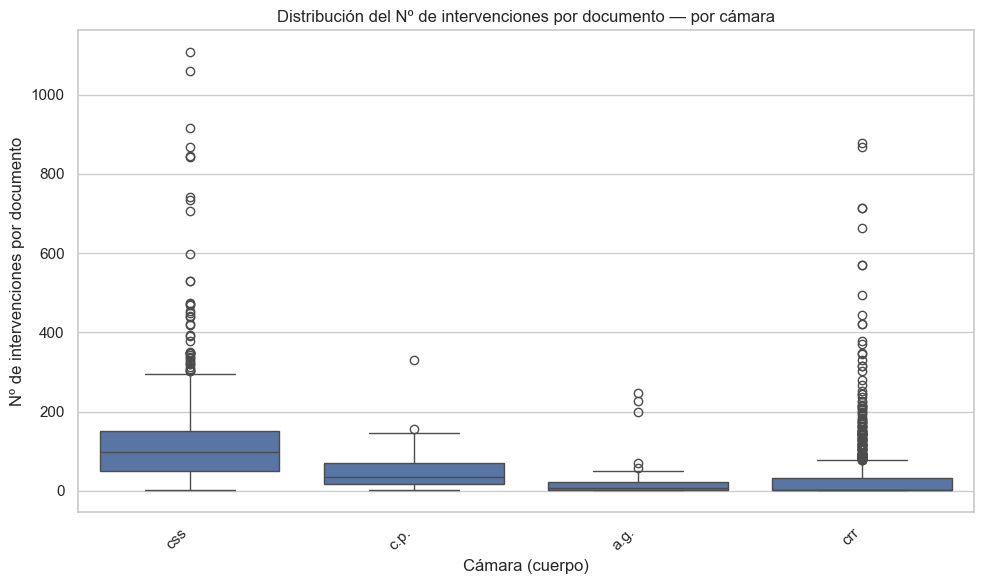

In [13]:
sns.set(style="whitegrid")

# Si ya tenés df cargado (cada fila = una intervención), usalo; si no, descomenta para cargar:
# df = pd.read_json("../data/interim/debates.jsonl", lines=True)

# Saneo mínimo
df = df.copy()
if 'file_name' not in df.columns:
    df['file_name'] = 'unknown_file'
if 'cuerpo' not in df.columns:
    df['cuerpo'] = 'DESCONOCIDO'
df['cuerpo'] = df['cuerpo'].fillna('DESCONOCIDO')

# Conteo de intervenciones por documento
counts = (df.groupby(['file_name','cuerpo'])
            .size()
            .reset_index(name='n_intervenciones'))

# Ordenar cámaras por mediana para que el gráfico quede prolijo
order = (counts.groupby('cuerpo')['n_intervenciones']
               .median()
               .sort_values(ascending=False)
               .index)

plt.figure(figsize=(10,6))
sns.boxplot(data=counts, x='cuerpo', y='n_intervenciones', order=order)
plt.title('Distribución del Nº de intervenciones por documento — por cámara')
plt.xlabel('Cámara (cuerpo)')
plt.ylabel('Nº de intervenciones por documento')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [14]:
camaras = df["cuerpo"].value_counts()
camaras

cuerpo
css     99551
crr     32876
c.p.     5349
a.g.     1717
Name: count, dtype: int64

([0, 1, 2, 3],
 [Text(0, 0, 'css'),
  Text(1, 0, 'crr'),
  Text(2, 0, 'c.p.'),
  Text(3, 0, 'a.g.')])

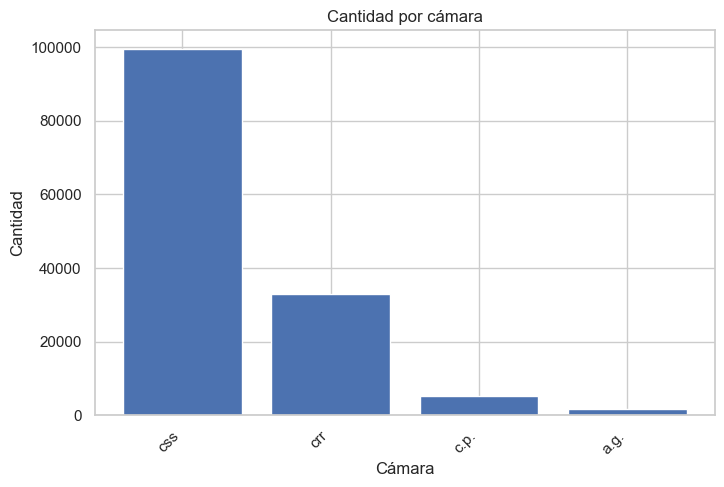

In [15]:
plt.figure(figsize=(8,5))
plt.bar(camaras.index.astype(str), camaras.values)
plt.title("Cantidad por cámara")
plt.xlabel("Cámara")
plt.ylabel("Cantidad")
plt.xticks(rotation=45, ha='right')


In [20]:
prueba = df[df["cuerpo"]== "desconocido"]
prueba

,file_name,n_legislatura,cuerpo,fecha,locutor,encabezado,intervencion,n_palabras,n_caracteres,es_presidencia


In [16]:
pivot_docs = counts.pivot_table(index='file_name',
                                columns='cuerpo',
                                values='n_intervenciones',
                                fill_value=0,
                                aggfunc='sum').reset_index()
display(pivot_docs)


cuerpo,file_name,a.g.,c.p.,crr,css
0,47_2010-02-15_crr.txt,0,0,45,0
1,47_2010-02-15_css.txt,0,0,0,96
2,47_2010-02-18_css.txt,0,0,0,17
3,47_2010-03-02_crr.txt,0,0,19,0
4,47_2010-03-03_crr.txt,0,0,1,0
...,...,...,...,...,...
1995,50_2025-10-07_css.txt,0,0,0,110
1996,50_2025-10-10_css.txt,0,0,0,185
1997,50_2025-10-14_css.txt,0,0,0,419
1998,50_2025-10-15_css.txt,0,0,0,20


In [17]:
# Función para calcular stats "tipo boxplot" (whis = 1.5 * IQR)
def _box_stats(series, whis=1.5):
    s = pd.Series(series).dropna().astype(float).sort_values()
    if s.empty:
        return pd.Series({
            'count': 0, 'min': np.nan, 'q1': np.nan, 'median': np.nan, 'q3': np.nan,
            'max': np.nan, 'iqr': np.nan, 'whisker_low': np.nan, 'whisker_high': np.nan,
            'mean': np.nan, 'std': np.nan, 'n_outliers': 0
        })

    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    median = s.median()
    iqr = q3 - q1

    # Límites teóricos de whiskers según regla 1.5 IQR
    lower_bound = q1 - whis * iqr
    upper_bound = q3 + whis * iqr

    # Whiskers reales (el dato más extremo dentro de los límites)
    whisker_low = s[s >= lower_bound].min()
    whisker_high = s[s <= upper_bound].max()

    # Outliers (fuera de whiskers)
    n_outliers = int(((s < whisker_low) | (s > whisker_high)).sum())

    return pd.Series({
        'count': int(s.size),
        'min': float(s.min()),
        'q1': float(q1),
        'median': float(median),
        'q3': float(q3),
        'max': float(s.max()),
        'iqr': float(iqr),
        'whisker_low': float(whisker_low),
        'whisker_high': float(whisker_high),
        'mean': float(s.mean()),
        'std': float(s.std(ddof=1)) if s.size > 1 else np.nan,
        'n_outliers': n_outliers
    })

# Calcula stats por cámara (cuerpo) usando los "n_intervenciones" del boxplot
box_stats = (
    counts.groupby('cuerpo')['n_intervenciones']
          .apply(_box_stats)
          .reset_index()
)

# Ordena igual que el boxplot (por mediana descendente, usando tu `order`)
box_stats = (box_stats
             .set_index('cuerpo')
             .loc[list(order)]
             .reset_index())

# Si querés verlas
from IPython.display import display
display(box_stats.style.format({
    'min': '{:.0f}', 'q1': '{:.1f}', 'median': '{:.1f}', 'q3': '{:.1f}', 'max': '{:.0f}',
    'iqr': '{:.1f}', 'whisker_low': '{:.1f}', 'whisker_high': '{:.1f}',
    'mean': '{:.2f}', 'std': '{:.2f}'
}))

,cuerpo,level_1,n_intervenciones
0,css,count,833.000000
1,css,min,1.000000
2,css,q1,50.000000
3,css,median,97.000000
4,css,q3,150.000000
5,css,max,1107.000000
6,css,iqr,100.000000
7,css,whisker_low,1.000000
8,css,whisker_high,295.000000
9,css,mean,119.509004


In [18]:
# --- Top 15 locutores (tabla con valores absolutos y %), excluyendo Presidencia ---
import pandas as pd

# Evitar problemas con NaN y filtrar cualquier variante de Presidente/a
locs = df['locutor'].fillna('').astype(str)
mask_presi = locs.str.contains(r'\bPRESIDENT(A|E)\b', case=False, regex=True)
locs = locs[~mask_presi].str.strip()

# (Opcional) limpiar honoríficos al inicio para unificar nombres
# locs = locs.str.replace(r'^(SEÑOR(A)?|SR\.?|SRA\.?|DR\.?|DRA\.?)\s+', '', regex=True, flags=0)

# Conteo y top 15
counts_all = locs.value_counts(dropna=False)
top15 = (counts_all.head(15)
         .to_frame(name='intervenciones')
         .reset_index()
         .rename(columns={'index': 'locutor'}))

total_interv = counts_all.sum()
top15['porcentaje']   = 100 * top15['intervenciones'] / total_interv
top15['acumulado_%']  = top15['porcentaje'].cumsum()
top15['rank']         = range(1, len(top15) + 1)

# Orden y formato
cols = ['rank', 'locutor', 'intervenciones', 'porcentaje', 'acumulado_%']
top15 = top15[cols]

from IPython.display import display
display(top15.style.format({'porcentaje': '{:.2f}%', 'acumulado_%': '{:.2f}%'}))

# (Opcional) guardar a CSV para reporte
# top15.to_csv('top15_locutores_sin_presidencia.csv', index=False)


/var/folders/rt/c3kdzpyd2fdflbk7kfmpz4sh0000gn/T/ipykernel_95170/238692040.py:6: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  mask_presi = locs.str.contains(r'\bPRESIDENT(A|E)\b', case=False, regex=True)


,rank,locutor,intervenciones,porcentaje,acumulado_%
0,1,SEÑOR BORDABERRY,2686,4.09%,4.09%
1,2,SEÑOR MICHELINI,2326,3.54%,7.63%
2,3,SEÑOR HEBER,1612,2.45%,10.08%
3,4,SEÑOR PENADÉS,1498,2.28%,12.36%
4,5,SEÑORA BIANCHI,1391,2.12%,14.48%
5,6,SEÑOR RUBIO,1217,1.85%,16.33%
6,7,SEÑOR PASQUET,1158,1.76%,18.10%
7,8,SEÑOR BOTANA,1032,1.57%,19.67%
8,9,SEÑOR DELGADO,987,1.50%,21.17%
9,10,SEÑOR ABREU,966,1.47%,22.64%


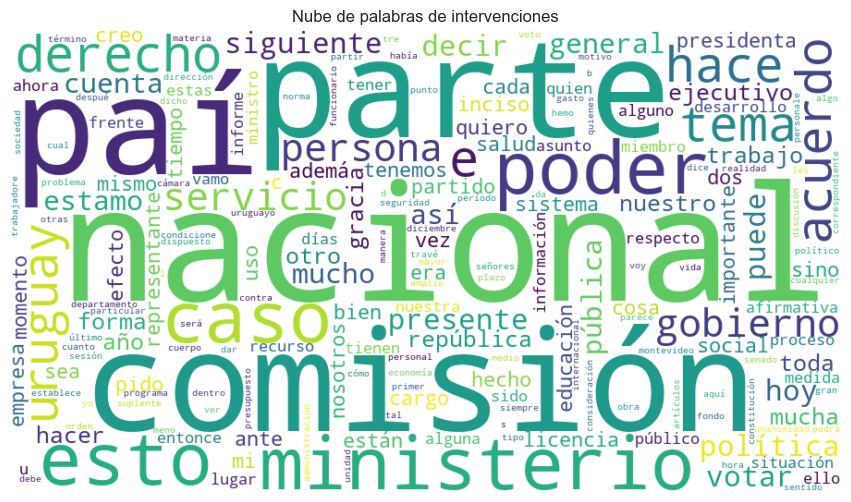

In [19]:
# ------------------------
# 8. Nube de palabras (quitando artículos, preps, etc.)
# ------------------------
stopwords = set([
    "de","la","que","el","en","y","a","los","del","se","las","por","un",
    "con","no","una","su","para","es","al","lo","como","más","pero","sus",
    "le","ya","o","fue","ha","si","sin","sobre","este","también","me","hasta",
    "hay","donde","han","ser","uno","entre","cuando","muy","años","desde",
    "porque","qué","solo","nos","durante","todo","esta","todos","sí","pues",
    "ni","misma","ese","otra","tanto","otros","ese","esa","ese","esas","estos","articulo","señor","señora",
    "palabra", "ley", "presidente", "día", "proyecto", "senador", "diputado", "senadora", "diputada",
    "va", "día", "n", "está", "artículo", "tiene","son", "eso", "estado"
,])

texto = " ".join(df["intervencion"].tolist())
texto = re.sub(r"[^a-zA-ZáéíóúÁÉÍÓÚñÑ ]", " ", texto)
texto = " ".join([t.lower() for t in texto.split() if t.lower() not in stopwords])

wc = WordCloud(width=900, height=500, background_color="white", collocations=False).generate(texto)
plt.figure(figsize=(12,6))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("Nube de palabras de intervenciones")
plt.show()



Porcentaje de palabras por cámara:
cuerpo
a.g.     1.19
c.p.     4.08
crr     43.75
css     50.98
Name: n_palabras, dtype: float64


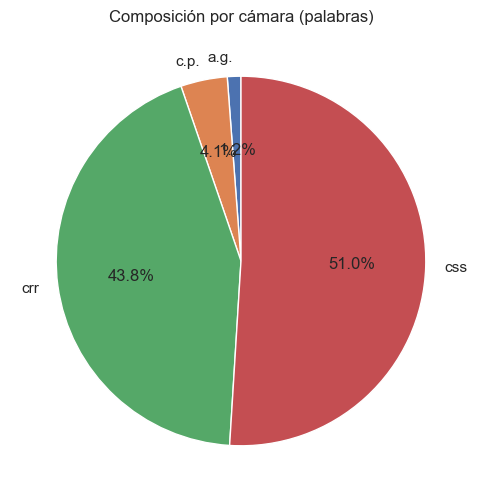

In [20]:
# ------------------------
# 9. Composición por cámara (% de palabras)
# ------------------------
palabras_por_cuerpo = df.groupby("cuerpo")["n_palabras"].sum()
palabras_por_cuerpo_pct = (palabras_por_cuerpo / palabras_por_cuerpo.sum()) * 100
print("\nPorcentaje de palabras por cámara:")
print(palabras_por_cuerpo_pct.round(2))

plt.figure(figsize=(6,6))
palabras_por_cuerpo_pct.plot(kind="pie", autopct="%.1f%%", startangle=90)
plt.title("Composición por cámara (palabras)")
plt.ylabel("")
plt.show()

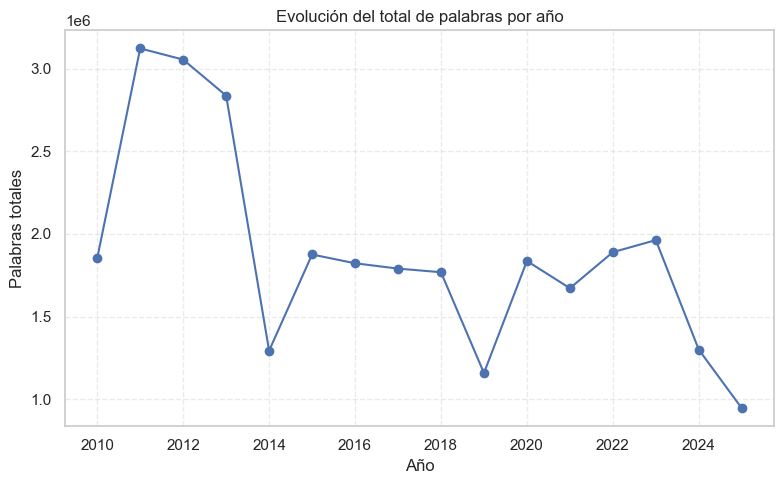

In [21]:
# ------------------------
# 10. Bonus: evolución temporal
# ------------------------
df["fecha"] = pd.to_datetime(df["fecha"], errors="coerce")
df["año"] = df["fecha"].dt.year
evol = df.groupby("año")["n_palabras"].sum().dropna()

plt.figure(figsize=(8,5))
evol.plot(marker="o")
plt.title("Evolución del total de palabras por año")
plt.xlabel("Año")
plt.ylabel("Palabras totales")
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

In [22]:
# mujeres vs hombres

# Aseguramos que no haya NaN y pasamos a string
locs = df["locutor"].fillna("").astype(str)

# Filtramos fuera a Presidente/a
mask_presi = locs.str.contains(r'\bPRESIDENT(A|E)\b', case=False, regex=True)
locs_filtrados = locs[~mask_presi].str.strip()

# Clasificamos por género según el prefijo
def clasificar_genero(nombre):
    nombre_upper = nombre.upper()
    if nombre_upper.startswith("SEÑORA "):
        return "Mujer"
    elif nombre_upper.startswith("SEÑOR "):
        return "Hombre"
    else:
        return "No identificado"

df_genero = pd.DataFrame({
    "locutor": locs_filtrados,
    "genero": locs_filtrados.map(clasificar_genero)
})

# Contamos las intervenciones por género
conteo = df_genero["genero"].value_counts().reset_index()
conteo.columns = ["Género", "Intervenciones"]
conteo["Porcentaje"] = 100 * conteo["Intervenciones"] / conteo["Intervenciones"].sum()

from IPython.display import display
display(conteo.style.format({"Porcentaje": "{:.2f}%"}))

# Totales absolutos
total = conteo["Intervenciones"].sum()
print(f"Total de intervenciones (sin Presidencia): {total:,}")


/var/folders/rt/c3kdzpyd2fdflbk7kfmpz4sh0000gn/T/ipykernel_95170/1586804477.py:7: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  mask_presi = locs.str.contains(r'\bPRESIDENT(A|E)\b', case=False, regex=True)


,Género,Intervenciones,Porcentaje
0,Hombre,54048,82.28%
1,Mujer,11265,17.15%
2,No identificado,378,0.58%


Total de intervenciones (sin Presidencia): 65,691


In [23]:
idx_validos = locs_filtrados.index

# Subset con cámara y locutor
df_sub = df.loc[idx_validos, ["cuerpo", "locutor"]].copy()
df_sub["cuerpo"] = df_sub["cuerpo"].fillna("DESCONOCIDO")

# Reutilizamos la misma función de clasificación
df_sub["genero"] = df_sub["locutor"].map(clasificar_genero)

# Tabla larga: absolutos y % dentro de cada cámara
tabla_genero_camara = (
    df_sub.groupby(["cuerpo", "genero"])
          .size()
          .reset_index(name="intervenciones")
)

tabla_genero_camara["total_cuerpo"] = tabla_genero_camara.groupby("cuerpo")["intervenciones"].transform("sum")
tabla_genero_camara["porcentaje"] = 100 * tabla_genero_camara["intervenciones"] / tabla_genero_camara["total_cuerpo"]

from IPython.display import display
display(
    tabla_genero_camara.sort_values(["cuerpo","genero"])
                       .style.format({"intervenciones": "{:,.0f}",
                                      "total_cuerpo": "{:,.0f}",
                                      "porcentaje": "{:.2f}%"}))

# --- Tabla pivote resumida: cámaras en filas, géneros en columnas ---
pivot_genero_camara = (
    tabla_genero_camara.pivot_table(
        index="cuerpo",
        columns="genero",
        values="intervenciones",
        aggfunc="sum",
        fill_value=0
    )
    .reset_index()
)

# Totales y % Mujer (útil para lectura rápida)
pivot_genero_camara["Total"] = pivot_genero_camara.drop(columns=["cuerpo"]).sum(axis=1)
if "Mujer" in pivot_genero_camara.columns:
    pivot_genero_camara["% Mujer"] = 100 * pivot_genero_camara["Mujer"] / pivot_genero_camara["Total"]
if "Hombre" in pivot_genero_camara.columns:
    pivot_genero_camara["% Hombre"] = 100 * pivot_genero_camara["Hombre"] / pivot_genero_camara["Total"]

# Ordenar por Total descendente
cols_fmt = {c: "{:,.0f}" for c in pivot_genero_camara.columns if c not in ["cuerpo", "% Mujer", "% Hombre"]}
cols_fmt.update({"% Mujer": "{:.2f}%", "% Hombre": "{:.2f}%"})

display(
    pivot_genero_camara.sort_values("Total", ascending=False)
                       .style.format(cols_fmt)
)

,cuerpo,genero,intervenciones,total_cuerpo,porcentaje
0,a.g.,Hombre,756,"1,034",73.11%
1,a.g.,Mujer,263,"1,034",25.44%
2,a.g.,No identificado,15,"1,034",1.45%
3,c.p.,Hombre,"2,326","2,763",84.18%
4,c.p.,Mujer,434,"2,763",15.71%
5,c.p.,No identificado,3,"2,763",0.11%
6,crr,Hombre,"11,386","12,979",87.73%
7,crr,Mujer,"1,237","12,979",9.53%
8,crr,No identificado,356,"12,979",2.74%
9,css,Hombre,"39,580","48,915",80.92%


genero,cuerpo,Hombre,Mujer,No identificado,Total,% Mujer,% Hombre
3,css,"39,580","9,331",4,"48,915",19.08%,80.92%
2,crr,"11,386","1,237",356,"12,979",9.53%,87.73%
1,c.p.,"2,326",434,3,"2,763",15.71%,84.18%
0,a.g.,756,263,15,"1,034",25.44%,73.11%


In [24]:
desconocido = df_sub [df_sub["genero"]=="No identificado"]
desconocido


,cuerpo,locutor,genero
62,a.g.,DESCONOCIDO,No identificado
181,a.g.,DESCONOCIDO,No identificado
221,a.g.,DESCONOCIDO,No identificado
249,a.g.,DESCONOCIDO,No identificado
260,a.g.,DESCONOCIDO,No identificado
...,...,...,...
39941,crr,DESCONOCIDO,No identificado
47288,css,DESCONOCIDO,No identificado
65501,css,DESCONOCIDO,No identificado
72148,css,DESCONOCIDO,No identificado


In [25]:
# ¿Qué valores reales tiene la columna?
print(df_sub["genero"].value_counts(dropna=False))

# ¿Hay NAs?
print("NAs en genero:", df_sub["genero"].isna().sum())

# Muestra 20 filas ejemplo con el valor de genero que más aparece
top_valor = df_sub["genero"].value_counts().idxmax()
display(df_sub[df_sub["genero"].eq(top_valor)].head(20))


genero
Hombre             54048
Mujer              11265
No identificado      378
Name: count, dtype: int64
NAs en genero: 0


,cuerpo,locutor,genero
0,a.g.,SEÑOR SECRETARIO,Hombre
1,a.g.,SEÑOR SECRETARIO,Hombre
6,a.g.,SEÑOR SECRETARIO,Hombre
7,a.g.,SEÑOR SECRETARIO,Hombre
14,a.g.,SEÑOR HEBER,Hombre
16,a.g.,SEÑOR HEBER,Hombre
18,a.g.,SEÑOR POZZI,Hombre
20,a.g.,SEÑOR POZZI,Hombre
21,a.g.,SEÑOR POZZI,Hombre
22,a.g.,SEÑOR LACALLE POU,Hombre


In [26]:
# --- Evolución por legislaturas: cantidades y proporciones por género (sin Desconocido) ---

# Base con las columnas necesarias
df_leg = df.loc[idx_validos, ["n_legislatura", "cuerpo", "locutor"]].copy()

# Clasificación de género y filtro
df_leg["genero"] = df_leg["locutor"].map(clasificar_genero)
df_leg = df_leg[df_leg["genero"].isin(["Mujer", "Hombre"])]

# Tabla larga: conteos por legislatura y género
evo_genero_leg = (
    df_leg.groupby(["n_legislatura", "genero"])
          .size()
          .reset_index(name="intervenciones")
)

# Totales por legislatura y % dentro de cada legislatura
evo_genero_leg["total_leg"] = evo_genero_leg.groupby("n_legislatura")["intervenciones"].transform("sum")
evo_genero_leg["porcentaje"] = 100 * evo_genero_leg["intervenciones"] / evo_genero_leg["total_leg"]

# Mostrar ordenado por legislatura
from IPython.display import display
display(
    evo_genero_leg.sort_values(["n_legislatura", "genero"])
                  .style.format({"intervenciones": "{:,.0f}",
                                 "total_leg": "{:,.0f}",
                                 "porcentaje": "{:.2f}%"}))

# --- Versión pivote (una fila por legislatura) con % mujer ---

evo_genero_pivot = (
    evo_genero_leg.pivot_table(
        index="n_legislatura",
        columns="genero",
        values="intervenciones",
        aggfunc="sum",
        fill_value=0
    )
    .reset_index()
)

# Totales y proporciones
if {"Mujer","Hombre"}.issubset(evo_genero_pivot.columns):
    evo_genero_pivot["Total"] = evo_genero_pivot["Mujer"] + evo_genero_pivot["Hombre"]
    evo_genero_pivot["% Mujer"] = 100 * evo_genero_pivot["Mujer"] / evo_genero_pivot["Total"]
else:
    # Por si en alguna legislatura falta un género
    otras_cols = [c for c in evo_genero_pivot.columns if c not in ["n_legislatura"]]
    evo_genero_pivot["Total"] = evo_genero_pivot[otras_cols].sum(axis=1)
    if "Mujer" in evo_genero_pivot.columns:
        evo_genero_pivot["% Mujer"] = 100 * evo_genero_pivot["Mujer"] / evo_genero_pivot["Total"]

# Mostrar ordenado por n_legislatura asc
cols_fmt = {c: "{:,.0f}" for c in evo_genero_pivot.columns if c not in ["n_legislatura", "% Mujer"]}
cols_fmt.update({"% Mujer": "{:.2f}%"})
display(evo_genero_pivot.sort_values("n_legislatura").style.format(cols_fmt))


,n_legislatura,genero,intervenciones,total_leg,porcentaje
0,47,Hombre,"27,375","29,916",91.51%
1,47,Mujer,"2,541","29,916",8.49%
2,48,Hombre,"12,023","14,843",81.00%
3,48,Mujer,"2,820","14,843",19.00%
4,49,Hombre,"12,701","18,044",70.39%
5,49,Mujer,"5,343","18,044",29.61%
6,50,Hombre,"1,949","2,510",77.65%
7,50,Mujer,561,"2,510",22.35%


genero,n_legislatura,Hombre,Mujer,Total,% Mujer
0,47,"27,375","2,541","29,916",8.49%
1,48,"12,023","2,820","14,843",19.00%
2,49,"12,701","5,343","18,044",29.61%
3,50,"1,949",561,"2,510",22.35%


In [27]:
# contar cuantos documentos tienen solo una intervención

# --- Parámetro ---
X = 2  # "menos de X": si querés "una sola intervención", poné X = 2

# --- Conteo de intervenciones por documento ---
# Asumimos que cada fila es una intervención y que 'file_name' identifica al documento/sesión.
doc_counts = (
    df.groupby("file_name")
      .size()
      .rename("intervenciones")
      .reset_index()
)

# Cámara por documento (tomamos la primera que aparezca)
doc_camara = (
    df.groupby("file_name")["cuerpo"]
      .first()
      .reset_index()
)

# Merge
docs = doc_counts.merge(doc_camara, on="file_name", how="left")
docs["cuerpo"] = docs["cuerpo"].fillna("DESCONOCIDO")

# --- Resultados globales ---
docs_con_una = (docs["intervenciones"] == 1).sum()
docs_menos_X = (docs["intervenciones"] < X).sum()
total_docs   = docs.shape[0]

print(f"Total de documentos: {total_docs:,}")
print(f"Documentos con UNA intervención: {docs_con_una:,}")
print(f"Documentos con < {X} intervenciones: {docs_menos_X:,}")

# --- Tabla por cámara: distribución (total vs. <X) ---
tabla_camara = (
    docs.assign(es_menor_X = docs["intervenciones"] < X)
        .groupby("cuerpo")
        .agg(
            docs_total = ("file_name", "nunique"),
            docs_ltX   = ("es_menor_X", "sum"),
        )
        .reset_index()
)

tabla_camara["%_ltX"] = 100 * tabla_camara["docs_ltX"] / tabla_camara["docs_total"]

from IPython.display import display
display(
    tabla_camara.sort_values("docs_total", ascending=False)
                .style.format({"docs_total": "{:,.0f}",
                               "docs_ltX": "{:,.0f}",
                               "%_ltX": "{:.2f}%"}))

# --- (Opcional) Si querés ver explícitamente los docs con una sola intervención:
docs_una = docs.loc[docs["intervenciones"] == 1, ["file_name", "cuerpo", "intervenciones"]]
# display(docs_una.head())


Total de documentos: 2,000
Documentos con UNA intervención: 561
Documentos con < 2 intervenciones: 561


,cuerpo,docs_total,docs_ltX,%_ltX
2,crr,963,524,54.41%
3,css,833,9,1.08%
1,c.p.,115,4,3.48%
0,a.g.,89,24,26.97%


In [28]:
# Filtrar los docs con una sola intervención
docs_una_interv_prueba = interv_x_doc[interv_x_doc == 1]

print(f"Documentos con una sola intervención: {len(docs_una_interv_prueba):,}")
docs_una_interv_prueba.head()


Documentos con una sola intervención: 561


file_name
47_2010-03-03_crr.txt    1
47_2010-03-09_crr.txt    1
47_2010-03-16_crr.txt    1
47_2010-03-17_crr.txt    1
47_2010-04-07_crr.txt    1
dtype: int64